# Arbol de Clasifiacion

Nelson Escalante - 22046

Este archivo incluye los incisos del 6 al 8 de la seccion de actividades.

### SETUP

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

train_path = "../data/train.csv"
train = pd.read_csv(train_path)

### INCISO 6:

Creacion de la variable respuesta para clasificacion de casas.

Lo principal es observar nuevamente la distribucion de los precios de las casas para entender los datos de buena manera y crear una division apropiada.

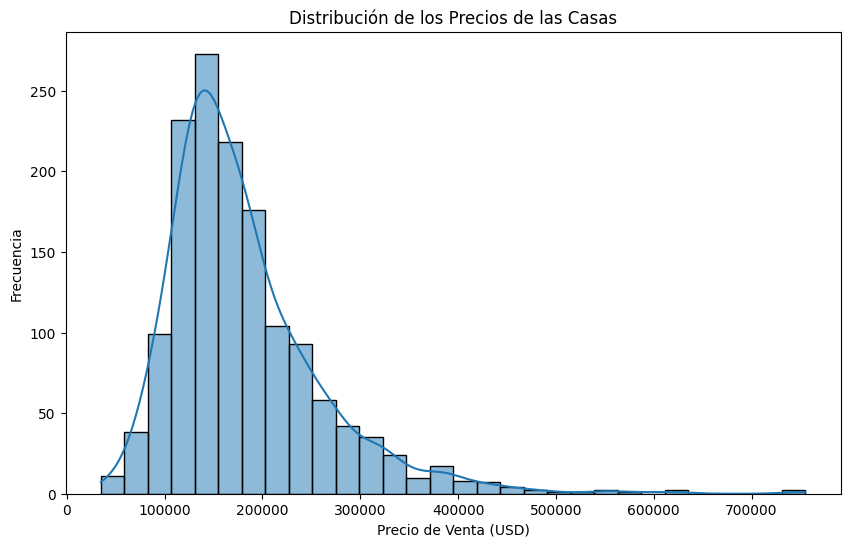

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(train["SalePrice"], bins=30, kde=True)
plt.title("Distribución de los Precios de las Casas")
plt.xlabel("Precio de Venta (USD)")
plt.ylabel("Frecuencia")
plt.show()

Podemos observar que la distribucion de las casas es una distribucion normal con sesgo positivo, lo que nos indica que hay pocas casas que tienen precios muy altos en relacion a las demas.

Para la creacion de nuestra nueva variable tenemos que tener en cuenta esta cualidad de los datos.

Utilizaremos percentiles para crear una division equitativa de los datos en base a los precios y su relacion entre si.

In [9]:
p33 = train["SalePrice"].quantile(0.33)
p66 = train["SalePrice"].quantile(0.66)

print(f"Límite Económicas: Menos de ${p33:,.0f}")
print(f"Límite Intermedias: Entre ${p33:,.0f} y ${p66:,.0f}")
print(f"Límite Caras: Más de ${p66:,.0f}")

Límite Económicas: Menos de $139,000
Límite Intermedias: Entre $139,000 y $189,893
Límite Caras: Más de $189,893


Con esta nueva division, nuestros datos se distribuyen entre los tres limites de manera equitativa. Vamos a crear la nueva variable con la informacion anterior.

In [10]:
def categorize_price(price):
    if price <= p33:
        return "Económica"
    elif price <= p66:
        return "Intermedia"
    else:
        return "Cara"

# Aplicar la función a la columna SalePrice
train["PriceCategory"] = train["SalePrice"].apply(categorize_price)

# Verificar distribución de clases
train["PriceCategory"].value_counts()

PriceCategory
Cara          497
Económica     483
Intermedia    480
Name: count, dtype: int64

Esta nueva variable servira para la creacion del arbol de clasificacion a base de los precios de las casas.